Loading dicom files ... This may take a moment.


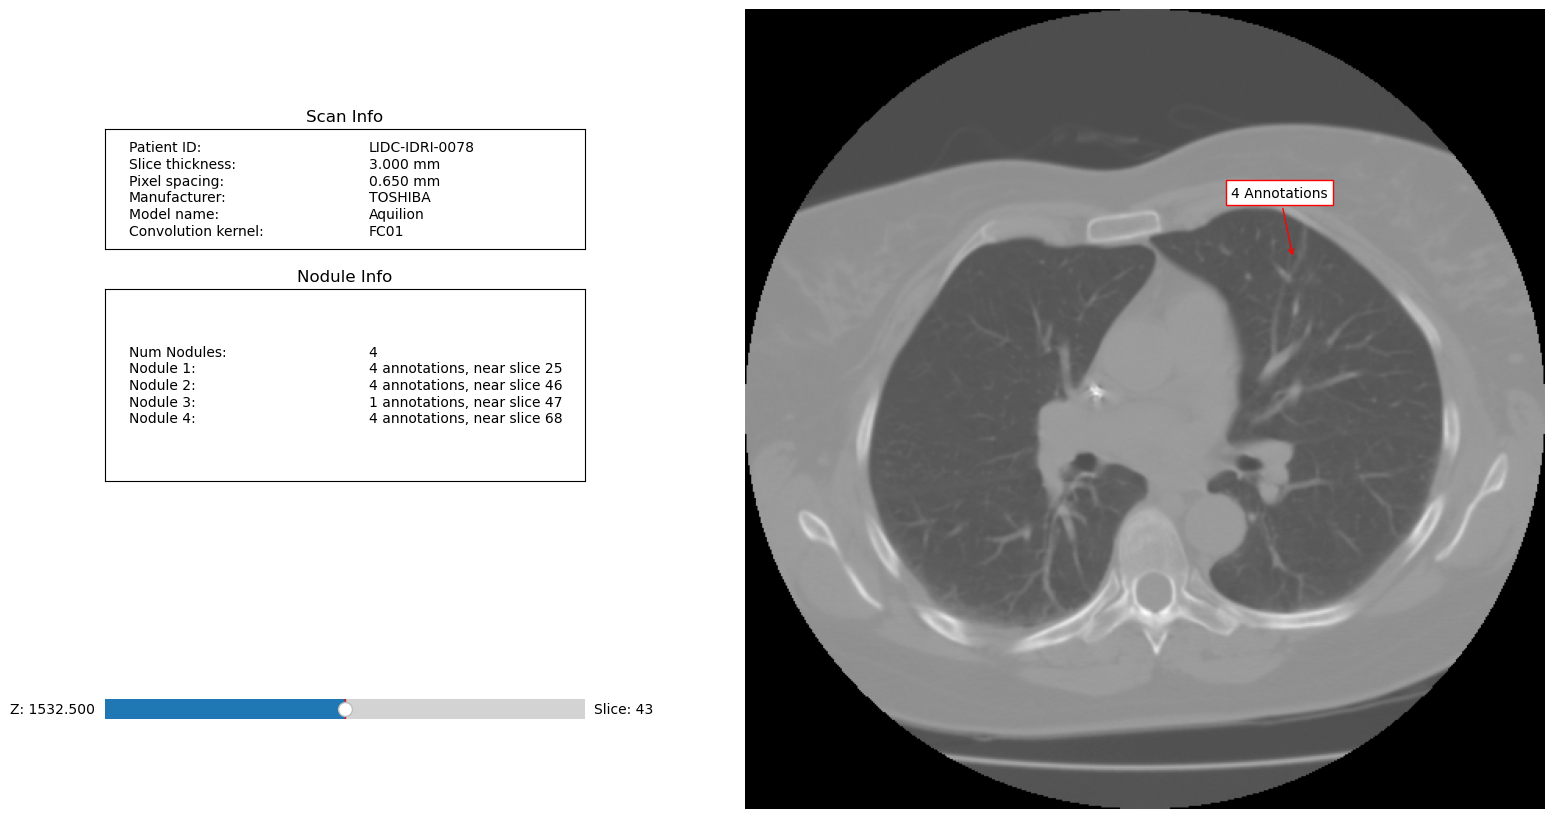

In [ ]:
import numpy as np
import pylidc as pl
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, Dropdown

pid = "LIDC-IDRI-0078"
scan = pl.query(pl.Scan).filter(pl.Scan.patient_id == pid).first()
vol = scan.to_volume()  # (Z, Y, X)

clusters = scan.cluster_annotations()
# 选一个 nodule cluster 来看，例如第0个
cluster_id = 0
cluster = clusters[cluster_id]

# 把每个 rater 的 mask 对齐到全局体数据坐标（pylidc 提供 bbox + boolean_mask）
def ann_to_global_mask(ann, shape):
    m = ann.boolean_mask(pad=0)  # local
    bbox = ann.bbox()
    g = np.zeros(shape, dtype=np.uint8)
    z0, y0, x0 = bbox[0].start, bbox[1].start, bbox[2].start
    g[z0:z0+m.shape[0], y0:y0+m.shape[1], x0:x0+m.shape[2]] = m.astype(np.uint8)
    return g

masks = [ann_to_global_mask(a, vol.shape) for a in cluster]
masks = np.stack(masks, axis=0)  # (R, Z, Y, X)

# 一个简单的 consensus
consensus = (masks.mean(0) >= 0.5).astype(np.uint8)

@interact(
    view=Dropdown(options=["axial(z)", "sagittal(x)", "coronal(y)"], value="axial(z)"),
    idx=IntSlider(min=0, max=vol.shape[0]-1, step=1, value=vol.shape[0]//2),
    rater=IntSlider(min=0, max=masks.shape[0]-1, step=1, value=0),
)
def show(view, idx, rater):
    plt.figure(figsize=(7,7))
    if view == "axial(z)":
        img = vol[idx,:,:]
        m_r = masks[rater, idx,:,:]
        m_c = consensus[idx,:,:]
        plt.title(f"Axial z={idx} | rater={rater}")
    elif view == "sagittal(x)":
        img = vol[:,:,idx]
        m_r = masks[rater, :, :, idx]
        m_c = consensus[:, :, idx]
        plt.title(f"Sagittal x={idx} | rater={rater}")
    else:
        img = vol[:,idx,:]
        m_r = masks[rater, :, idx, :]
        m_c = consensus[:, idx, :]
        plt.title(f"Coronal y={idx} | rater={rater}")

    plt.imshow(img, cmap="gray")
    # 红色：当前 rater；绿色：consensus
    plt.contour(m_r, levels=[0.5], linewidths=1)
    plt.contour(m_c, levels=[0.5], linewidths=1)
    plt.axis("off")
    plt.show()


In [ ]:
# 1. 安装必要的库 (如果没有的话)
# !pip install ipywidgets matplotlib

import pylidc as pl
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, IntSlider
import ipywidgets as widgets

# 2. 读取数据
pid = 'LIDC-IDRI-0078'
scan = pl.query(pl.Scan).filter(pl.Scan.patient_id == pid).first()
vol = scan.to_volume()

# 3. 预处理所有医生的标注 (为了流畅滑动，先算好)
nods = scan.cluster_annotations(verbose=False)
# 创建一个和 CT 一样大的空数组，用来存标注
# 0=背景, 1,2,3,4... 代表不同医生的标注叠加
mask_overlay = np.zeros(vol.shape, dtype=np.uint8)

print(f"正在加载标注... (共 {len(nods)} 个结节簇)")
for i, cluster in enumerate(nods):
    for ann in cluster:
        # 获取该标注的局部 mask 和 bbox
        m = ann.boolean_mask(pad=0)
        bbox = ann.bbox()
        # 将局部 mask 填入全局 mask_overlay
        # 注意：这里简单的将所有医生的 mask 叠加，重叠区域数值会 >1
        mask_overlay[bbox] += m.astype(np.uint8)

# 4. 定义交互绘图函数
def view_slice(z):
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    
    # 画 CT 底图 (肺窗)
    ax.imshow(vol[z, :, :], cmap='gray', vmin=-1200, vmax=600)
    
    # 画标注 (如果有的话)
    if np.max(mask_overlay[z, :, :]) > 0:
        # 使用半透明红色显示标注
        # mask > 0 的地方显示红色，alpha=0.3
        mask_slice = mask_overlay[z, :, :]
        # 创建一个 RGBA 图像用于叠加
        overlay = np.zeros(mask_slice.shape + (4,))
        overlay[mask_slice > 0] = [1, 0, 0, 0.4] # 红色，透明度 0.4
        ax.imshow(overlay)
        
        # 也可以画轮廓线，更清晰
        ax.contour(mask_slice > 0, colors='red', linewidths=0.5)
        
    ax.set_title(f"Patient: {pid} | Slice: Z={z}/{vol.shape[0]-1}")
    ax.axis('off')
    plt.show()

# 5. 启动交互界面
print("加载完成！请拖动下方滑块查看切片：")
interact(view_slice, 
         z=IntSlider(min=0, max=vol.shape[0]-1, step=1, value=vol.shape[0]//2, description='Slice Z:'));

Loading dicom files ... This may take a moment.
正在加载标注... (共 4 个结节簇)
加载完成！请拖动下方滑块查看切片：
